# Create SWOT image with different filter/ differentiation

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics, rotate_ggd
from cstes import swot_dir_2km, zarr_dir
from altimetry_filter import filter_diff_one, _concat, compute_filter_diff

__________
# CHOOSE SWOT dataset 


In [8]:
product = 'swot2km'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()

if product == 'swot250m':
    dfs = browse_swot_250m().reset_index()

______________________
# Example for one

In [3]:
dfs = browse_swot_2km().reset_index()
df3 = dfs[dfs.pass_number==3]
df16 = dfs[dfs.pass_number==16]
ds3 = df3.set_index('cycle_number').to_xarray()
ds16 = df16.set_index('cycle_number').to_xarray()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [5]:
ds16 = df16[(df16.cycle_number!=534)&(df16.cycle_number!=513)&(df16.cycle_number!=554) &(df16.cycle_number!=568)].set_index('cycle_number').to_xarray()

In [6]:
# Test
ds = ds16.chunk({'cycle_number':2}).persist()
# Test compute_filter_diff
C = compute_filter_diff(ds, filter_diff_method = 'gaussian', filter_diff_kwargs={'cutoff':20e3}, mean_sla=True).compute()
C

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

<xarray.Dataset> Size: 290MB
Dimensions:        (cycle_number: 91, num_lines: 481, num_pixels: 69)
Coordinates:
  * cycle_number   (cycle_number) int64 728B 478 479 481 482 ... 574 575 576 577
    longitude      (num_lines, num_pixels) float64 266kB 1.643 1.619 ... 2.616
    latitude       (num_lines, num_pixels) float64 266kB 43.63 43.62 ... 34.92
    time           (num_lines) datetime64[ns] 4kB 2023-07-09T18:56:22.0242337...
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    dxy_etaf       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dx_etaf        (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dxy_etac       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dy_etaf        (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dxx_etaf       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dy_etac        (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dyy_etaf       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dx_etac        (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dxx_etac       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    dyy_etac       (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    filtered_etaf  (cycle_number, num_lines, num_pixels) float64 24MB nan ......
    filtered_etac  (cycle_number, num_lines, num_pixels) float64 24MB nan ......

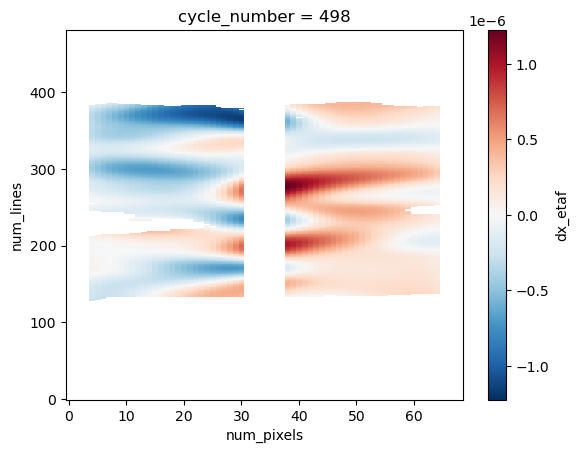

In [7]:
C.isel(cycle_number=19).dx_etaf.plot()

__________________
# 2km- Gaussian

In [2]:
method = 'gaussian'

# Gaussian 
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().persist()
    for cutoff in list(np.arange(4e3, 20e3, 2e3)) + list(np.arange(20e3, 60e3, 5e3)) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'cutoff':cutoff}, mean_sla=True, distance_to_coast_max=5e3).compute()
        C['pass_number'] = pass_
        C['cutoff'] = cutoff
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, method, f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
        print(cutoff)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


4000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1264: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

6000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1264: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_n
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/

...

45000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/bac

50000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1236: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice4)] - f[tuple(slice2)]) / (2. * ax_dx)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/numpy/lib/function_base.py:1257: RuntimeWarning: invalid value encountered in subtract
  out[tuple(slice1)] = (f[tuple(slice2)] - f[tuple(slice3)]) / dx_0
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/bac

55000.0


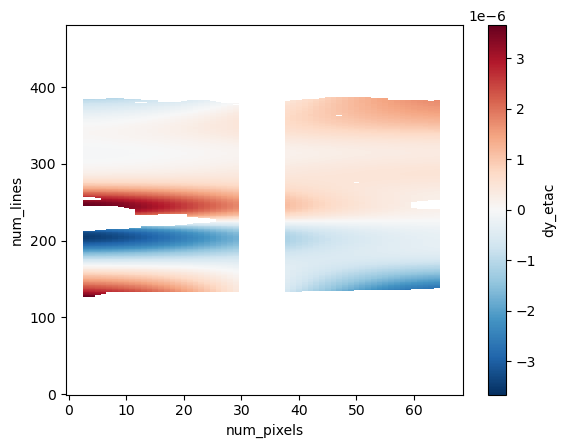

In [8]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot',product, 'gaussian', f'pass{pass_}_{product}_{method}_{int(cutoff)}.nc'))
(ds.isel(cycle_number= 90)-ds.isel(cycle_number= 80)).dy_etac.plot()

In [7]:
os.path.join(zarr_dir, 'before_coloc','preprocessed_swot')

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot'

__________________
# 2km- Diff_only

In [2]:
product = 'swot2km'
method = 'diff_only'

if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}, mean_sla=True).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


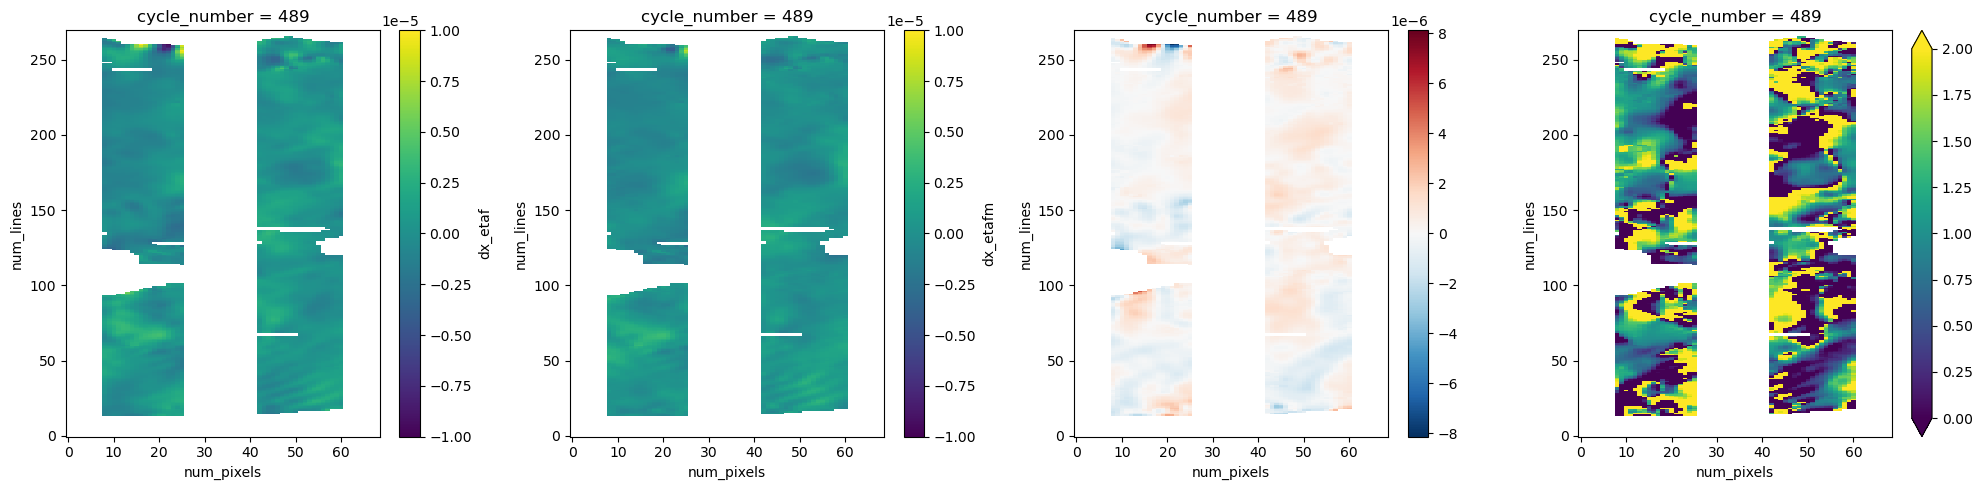

In [18]:
vmin, vmax = -1e-5, 1e-5
fig, axs = plt.subplots(1,4, figsize=(20, 5))
C.isel(cycle_number=10).dx_etaf.sel(num_lines = slice(120, 390)).plot(ax= axs[0], vmin=vmin, vmax=vmax, label = 'dx_etaf')
C.isel(cycle_number=10).dx_etafm.sel(num_lines = slice(120, 390)).plot(ax= axs[1], vmin=vmin, vmax=vmax, label = 'dx_etaf - mean sla')
(C.dx_etaf -C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[2])
(C.dx_etaf /C.dx_etafm).isel(cycle_number=10).sel(num_lines = slice(120, 390)).plot(ax= axs[3], vmin=0, vmax=2)
fig.tight_layout()

__________________
# 2km- xarray diff

In [8]:
method = 'xarray_diff'
    
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray()
    C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={}).compute()
    C['pass_number'] = pass_
    C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}.nc'))
        

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

In [5]:
zarr_dir

'/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC'

_____________
# 2km-Fitting Kernel

In [ ]:
method = 'fitting_kernel'

# Fitting kernel
from cstes import zarr_dir
for pass_ in [3, 16] :
    df = dfs[dfs.pass_number==pass_]
    ds_swot = df.set_index('cycle_number').to_xarray().chunk({'cycle_number':1}).persist()
    for npts in np.arange(5, 19, 2) :
        C = compute_filter_diff(ds_swot, filter_diff_method = method, filter_diff_kwargs={'npts':npts}).compute()
        C['pass_number'] = pass_
        C['npts'] = npts
        C.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_{product}_{method}_{int(npts)}.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

___________
# Dataset containing other general variables (that will be only interpolated, not diff)

In [3]:
def preprocess(ds):
    ds = add_grid_metrics(ds)
    c = ds.cycle_number.mean().values
    ds = ds.assign_coords({"cycle_number": ("cycle_number", [c])})
    return ds[variables]

variables = ['ancillary_surface_classification_flag',
             'cross_track_distance',
             'distance_to_coast',
             'duacs_editing_flag',
             'duacs_phase_screen',
             'duacs_phase_screen_orbit',
             'duacs_phase_screen_static',
             'duacs_relative_vorticity',
             'duacs_speed_meridional',
             'duacs_speed_meridional_abs',
             'duacs_speed_zonal',
             'duacs_speed_zonal_abs',
             'duacs_strain',
             'duacs_xcal',
             'sig0_karin_2',
             'phi',
             'swh_model', 
             'ssh_karin_uncert',
             'cycle_number'
            ]

In [4]:
# Drifters
dsg = {}
product = 'swot2km'
# Alti general
if product == 'swot2km':
    dfs = browse_swot_2km().reset_index()
    df3 = dfs[dfs.pass_number==3]
    df16 = dfs[dfs.pass_number==16]
    dsg[3] = xr.open_mfdataset(df3.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')
    dsg[16] = xr.open_mfdataset(df16.file.unique(), preprocess=preprocess, concat_dim='cycle_number', combine='nested')

for pass_ in [3, 16]:
    ds = dsg[pass_]
    ds['pass_number'] = pass_
    ds.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

NameError: name 'zarr_dir' is not defined

In [6]:
for pass_ in [3, 16]:
    ds = dsg[pass_]
    ds['pass_number'] = pass_
    ds.to_netcdf(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))


In [42]:
method = 'fitting_kernel'
product = 'swot2km'
f = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, method, f'pass{pass_}_*_swot2km_{method}.nc'))

In [11]:
dsg[3]

<xarray.Dataset> Size: 389MB
Dimensions:                                (cycle_number: 94, num_lines: 496,
                                            num_pixels: 69)
Coordinates:
    phi                                    (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
  * cycle_number                           (cycle_number) float64 752B 478.0 ...
    latitude                               (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    latitude_nadir                         (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    longitude                              (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    longitude_nadir                        (cycle_number, num_lines) float64 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    time                                   (cycle_number, num_lines) datetime64[ns] 373kB dask.array<chunksize=(1, 496), meta=np.ndarray>
    dx                                     (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
    dy                                     (num_lines, num_pixels) float64 274kB dask.array<chunksize=(496, 69), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/18)
    ancillary_surface_classification_flag  (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    cross_track_distance                   (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    distance_to_coast                      (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_editing_flag                     (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_phase_screen                     (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_phase_screen_orbit               (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    ...                                     ...
    duacs_strain                           (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    duacs_xcal                             (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    sig0_karin_2                           (cycle_number, num_lines, num_pixels) float32 13MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    swh_model                              (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    ssh_karin_uncert                       (cycle_number, num_lines, num_pixels) float64 26MB dask.array<chunksize=(1, 496, 69), meta=np.ndarray>
    pass_number                            int64 8B 3
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104

In [9]:
ds1 = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot', product, 'general', f'pass{pass_}_{product}_general.nc'))

In [10]:
ds1

<xarray.Dataset> Size: 365MB
Dimensions:                                (cycle_number: 91, num_lines: 481,
                                            num_pixels: 69)
Coordinates:
    phi                                    (num_lines, num_pixels) float64 266kB ...
  * cycle_number                           (cycle_number) float64 728B 478.0 ...
    latitude                               (num_lines, num_pixels) float64 266kB ...
    latitude_nadir                         (cycle_number, num_lines) float64 350kB ...
    longitude                              (num_lines, num_pixels) float64 266kB ...
    longitude_nadir                        (cycle_number, num_lines) float64 350kB ...
    time                                   (cycle_number, num_lines) datetime64[ns] 350kB ...
    dx                                     (num_lines, num_pixels) float64 266kB ...
    dy                                     (num_lines, num_pixels) float64 266kB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables: (12/18)
    ancillary_surface_classification_flag  (cycle_number, num_lines, num_pixels) float32 12MB ...
    cross_track_distance                   (cycle_number, num_lines, num_pixels) float32 12MB ...
    distance_to_coast                      (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_editing_flag                     (cycle_number, num_lines, num_pixels) float32 12MB ...
    duacs_phase_screen                     (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_phase_screen_orbit               (cycle_number, num_lines, num_pixels) float64 24MB ...
    ...                                     ...
    duacs_strain                           (cycle_number, num_lines, num_pixels) float64 24MB ...
    duacs_xcal                             (cycle_number, num_lines, num_pixels) float64 24MB ...
    sig0_karin_2                           (cycle_number, num_lines, num_pixels) float32 12MB ...
    swh_model                              (cycle_number, num_lines, num_pixels) float64 24MB ...
    ssh_karin_uncert                       (cycle_number, num_lines, num_pixels) float64 24MB ...
    pass_number                            int64 8B ...
Attributes:
    latc:     39.961324
    lonc:     4.3749
    phi:      76.80931729750104